In [60]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_formats="retina"

df = pd.read_excel("Dataset/so_bugs.xlsx")

In [61]:
def plot(df, dimension, figsize=(8, 6), ticklabelsize=14, legendsize=12):
    category_order = df[f"{dimension} Category"].value_counts().index.tolist()
    engine_order = df["Template Engine"].value_counts().index.tolist()

    crosstab_df = (
        pd.crosstab(
            df["Template Engine"], df[f"{dimension} Category"], normalize="index"
        )
        * 100
    )
    crosstab_df = crosstab_df.reindex(engine_order[::-1])[category_order]

    fig, ax = plt.subplots(figsize=figsize)
    fig.tight_layout()

    crosstab_df.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", width=0.7)
    ax.set_ylabel(None)
    ax.tick_params(axis="y", labelsize=ticklabelsize)
    ax.set_xlabel("Percentage (%)", fontsize=ticklabelsize)
    ax.tick_params(axis="x", labelsize=ticklabelsize)
    ax.set_xlim(0, 100)

    reorder = lambda hl, nc: (sum((lis[i::nc] for i in range(nc)), []) for lis in hl)
    ncol = min(3, len(category_order))
    h_l = ax.get_legend_handles_labels()

    ax.legend(
        *reorder(h_l, ncol),
        loc="upper center",
        bbox_to_anchor=(0.4, -0.08),
        ncol=ncol,
        fontsize=legendsize,
        frameon=False,
        # columnspacing=0.5,
    )

    # plt.savefig(f"figures/te_{dimension.lower().replace(' ', '_')}.pdf", bbox_inches="tight")

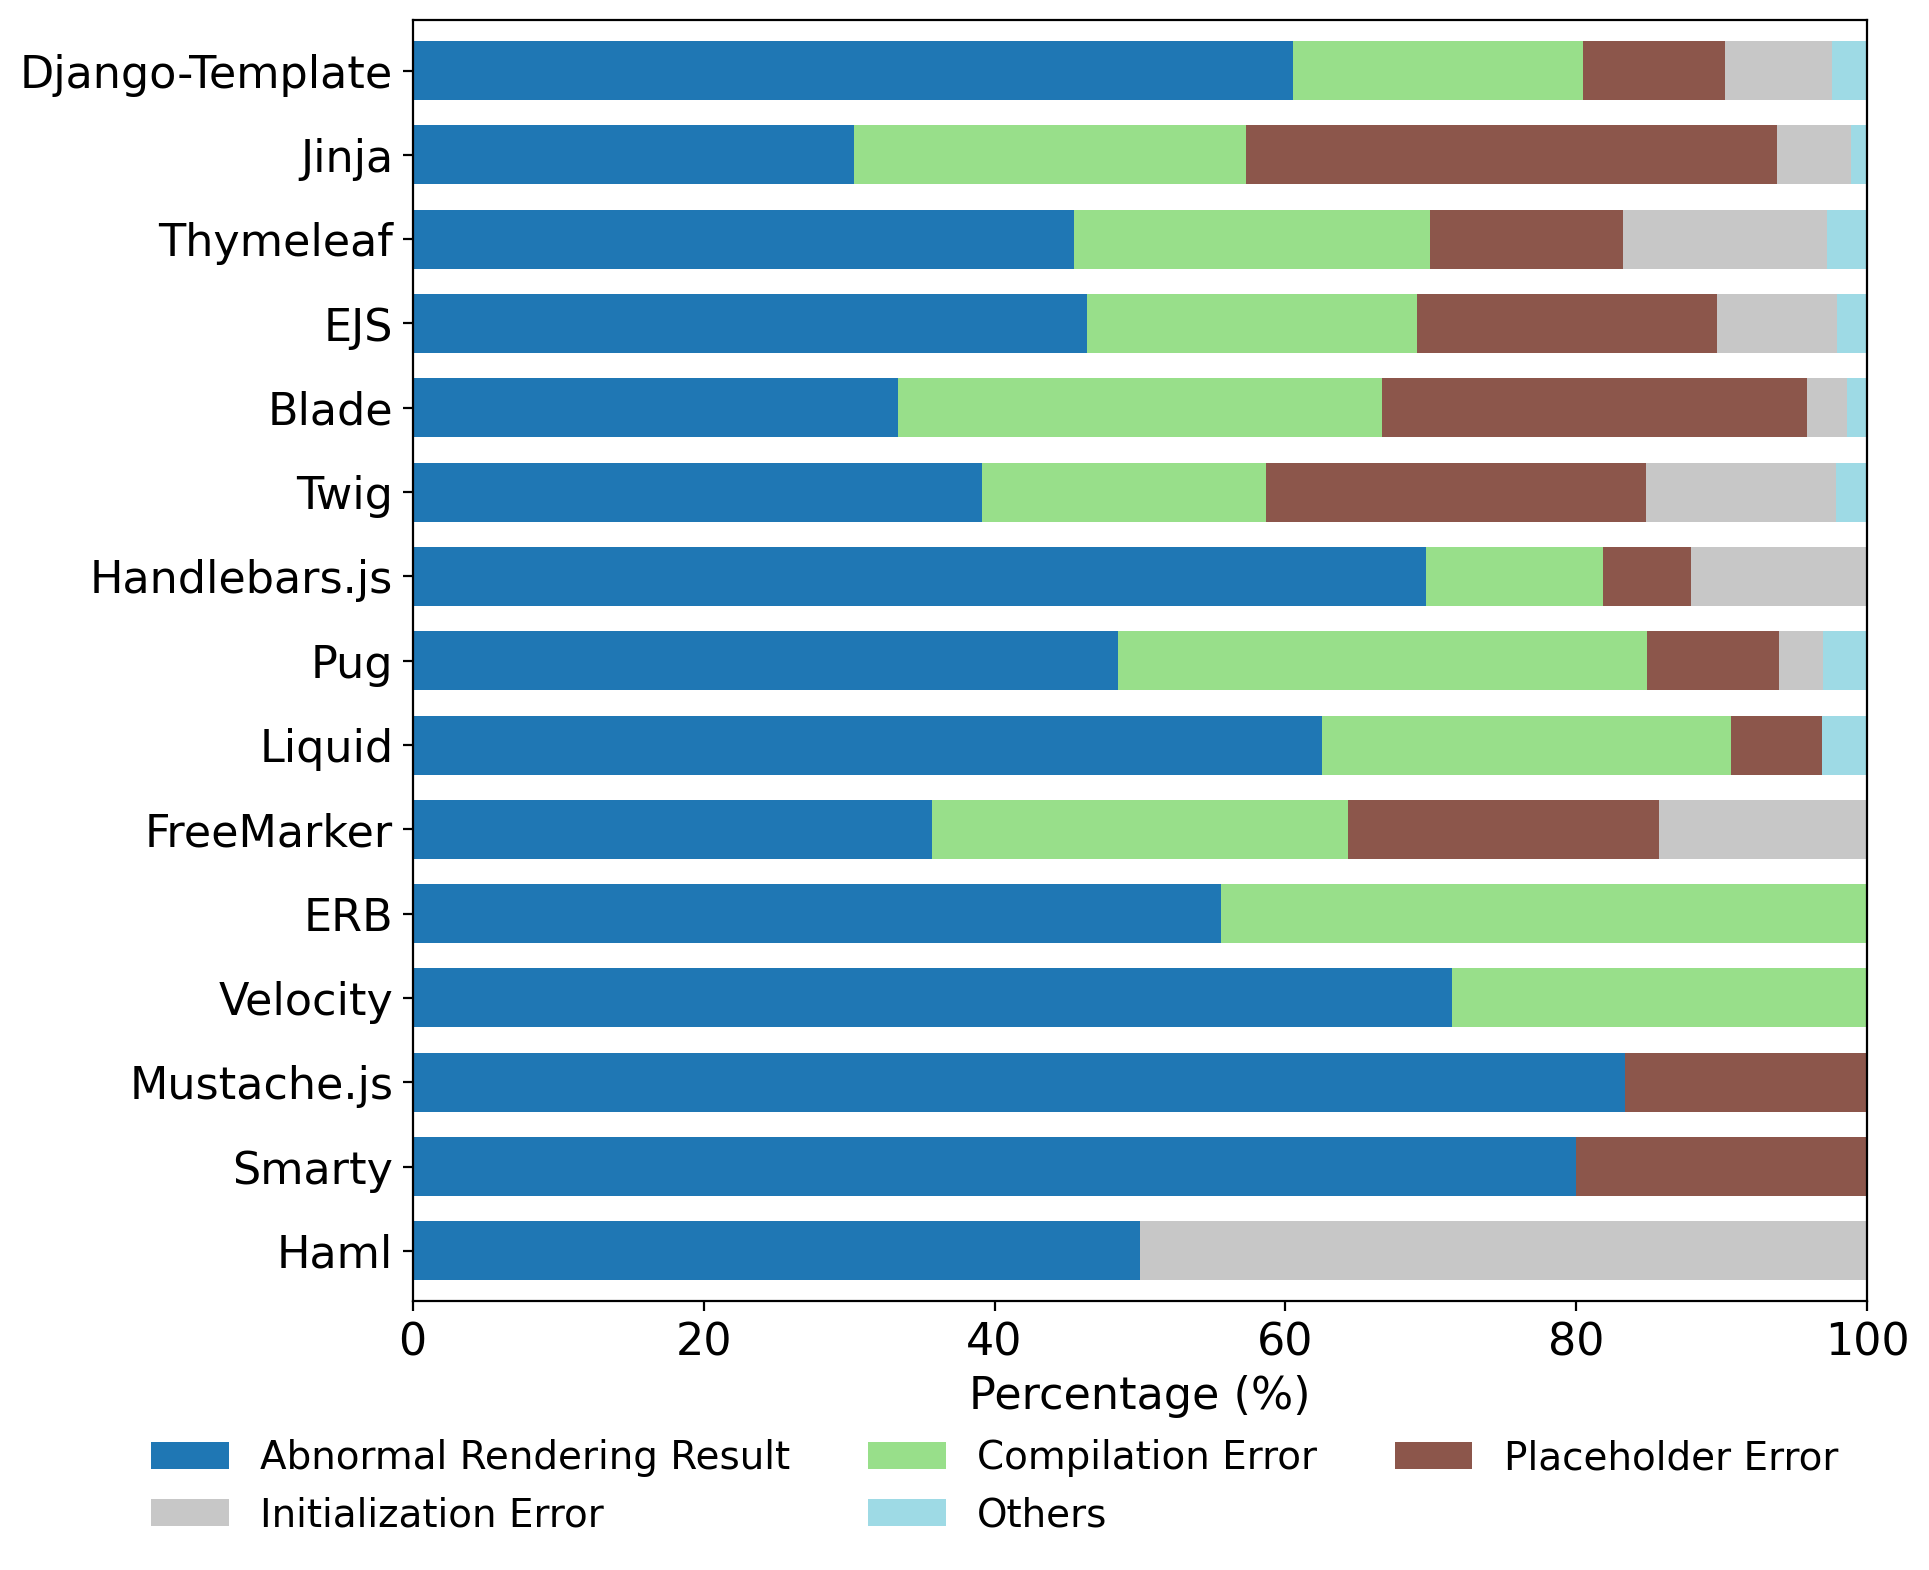

In [62]:
plot(df, "Symptom", figsize=(8, 7), ticklabelsize=16, legendsize=14)

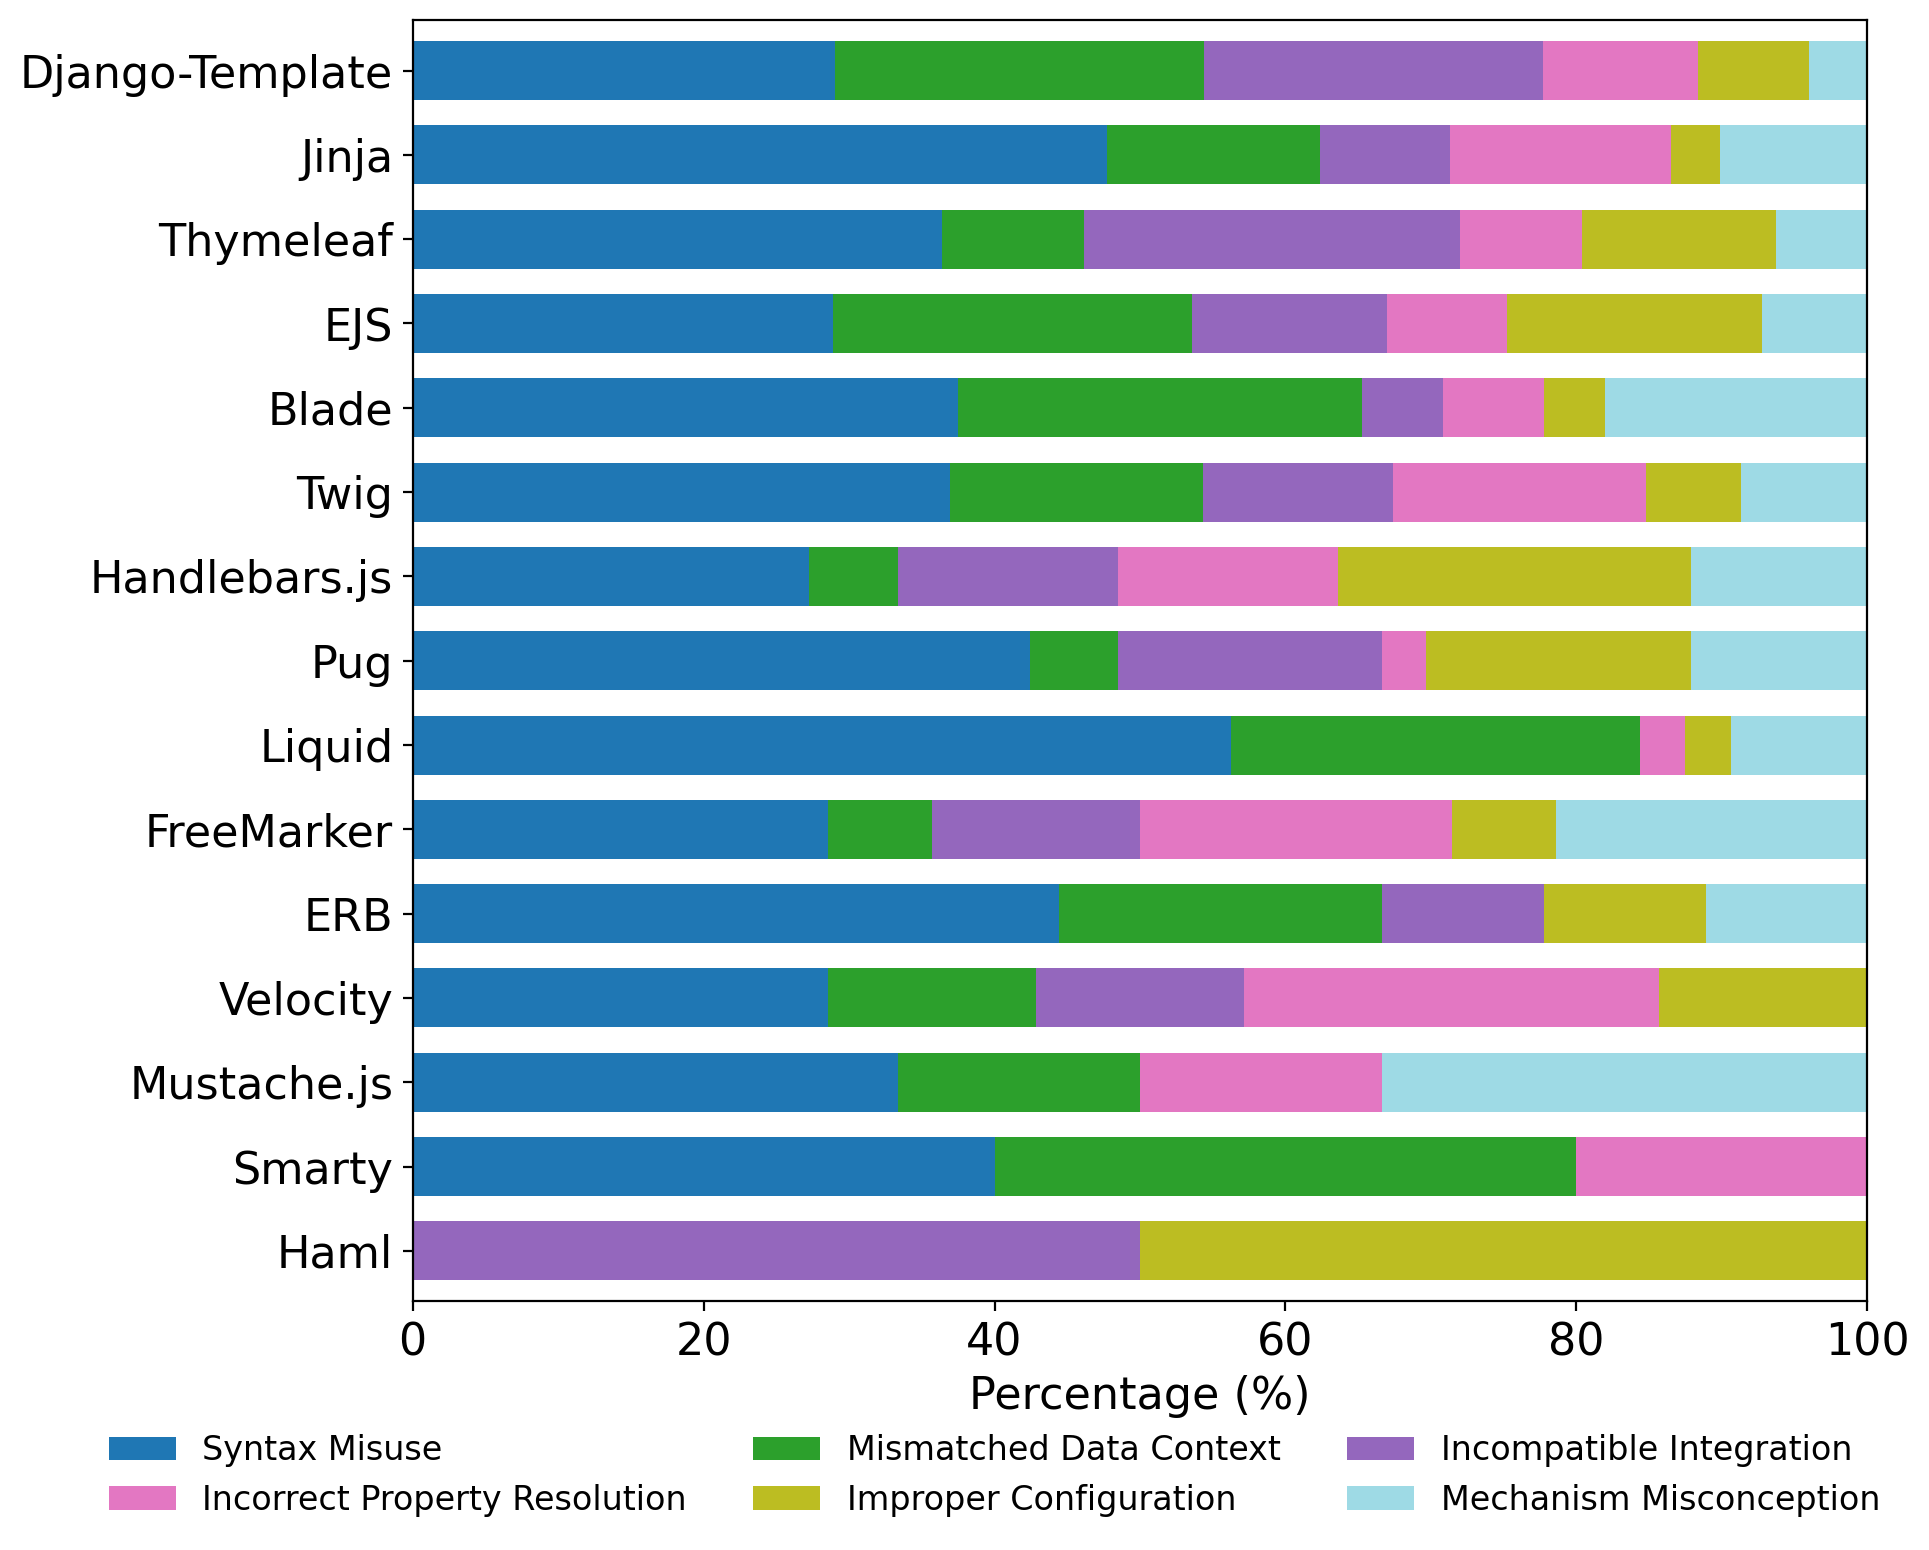

In [63]:
plot(df, "Root Cause", figsize=(8, 7), ticklabelsize=16, legendsize=12)

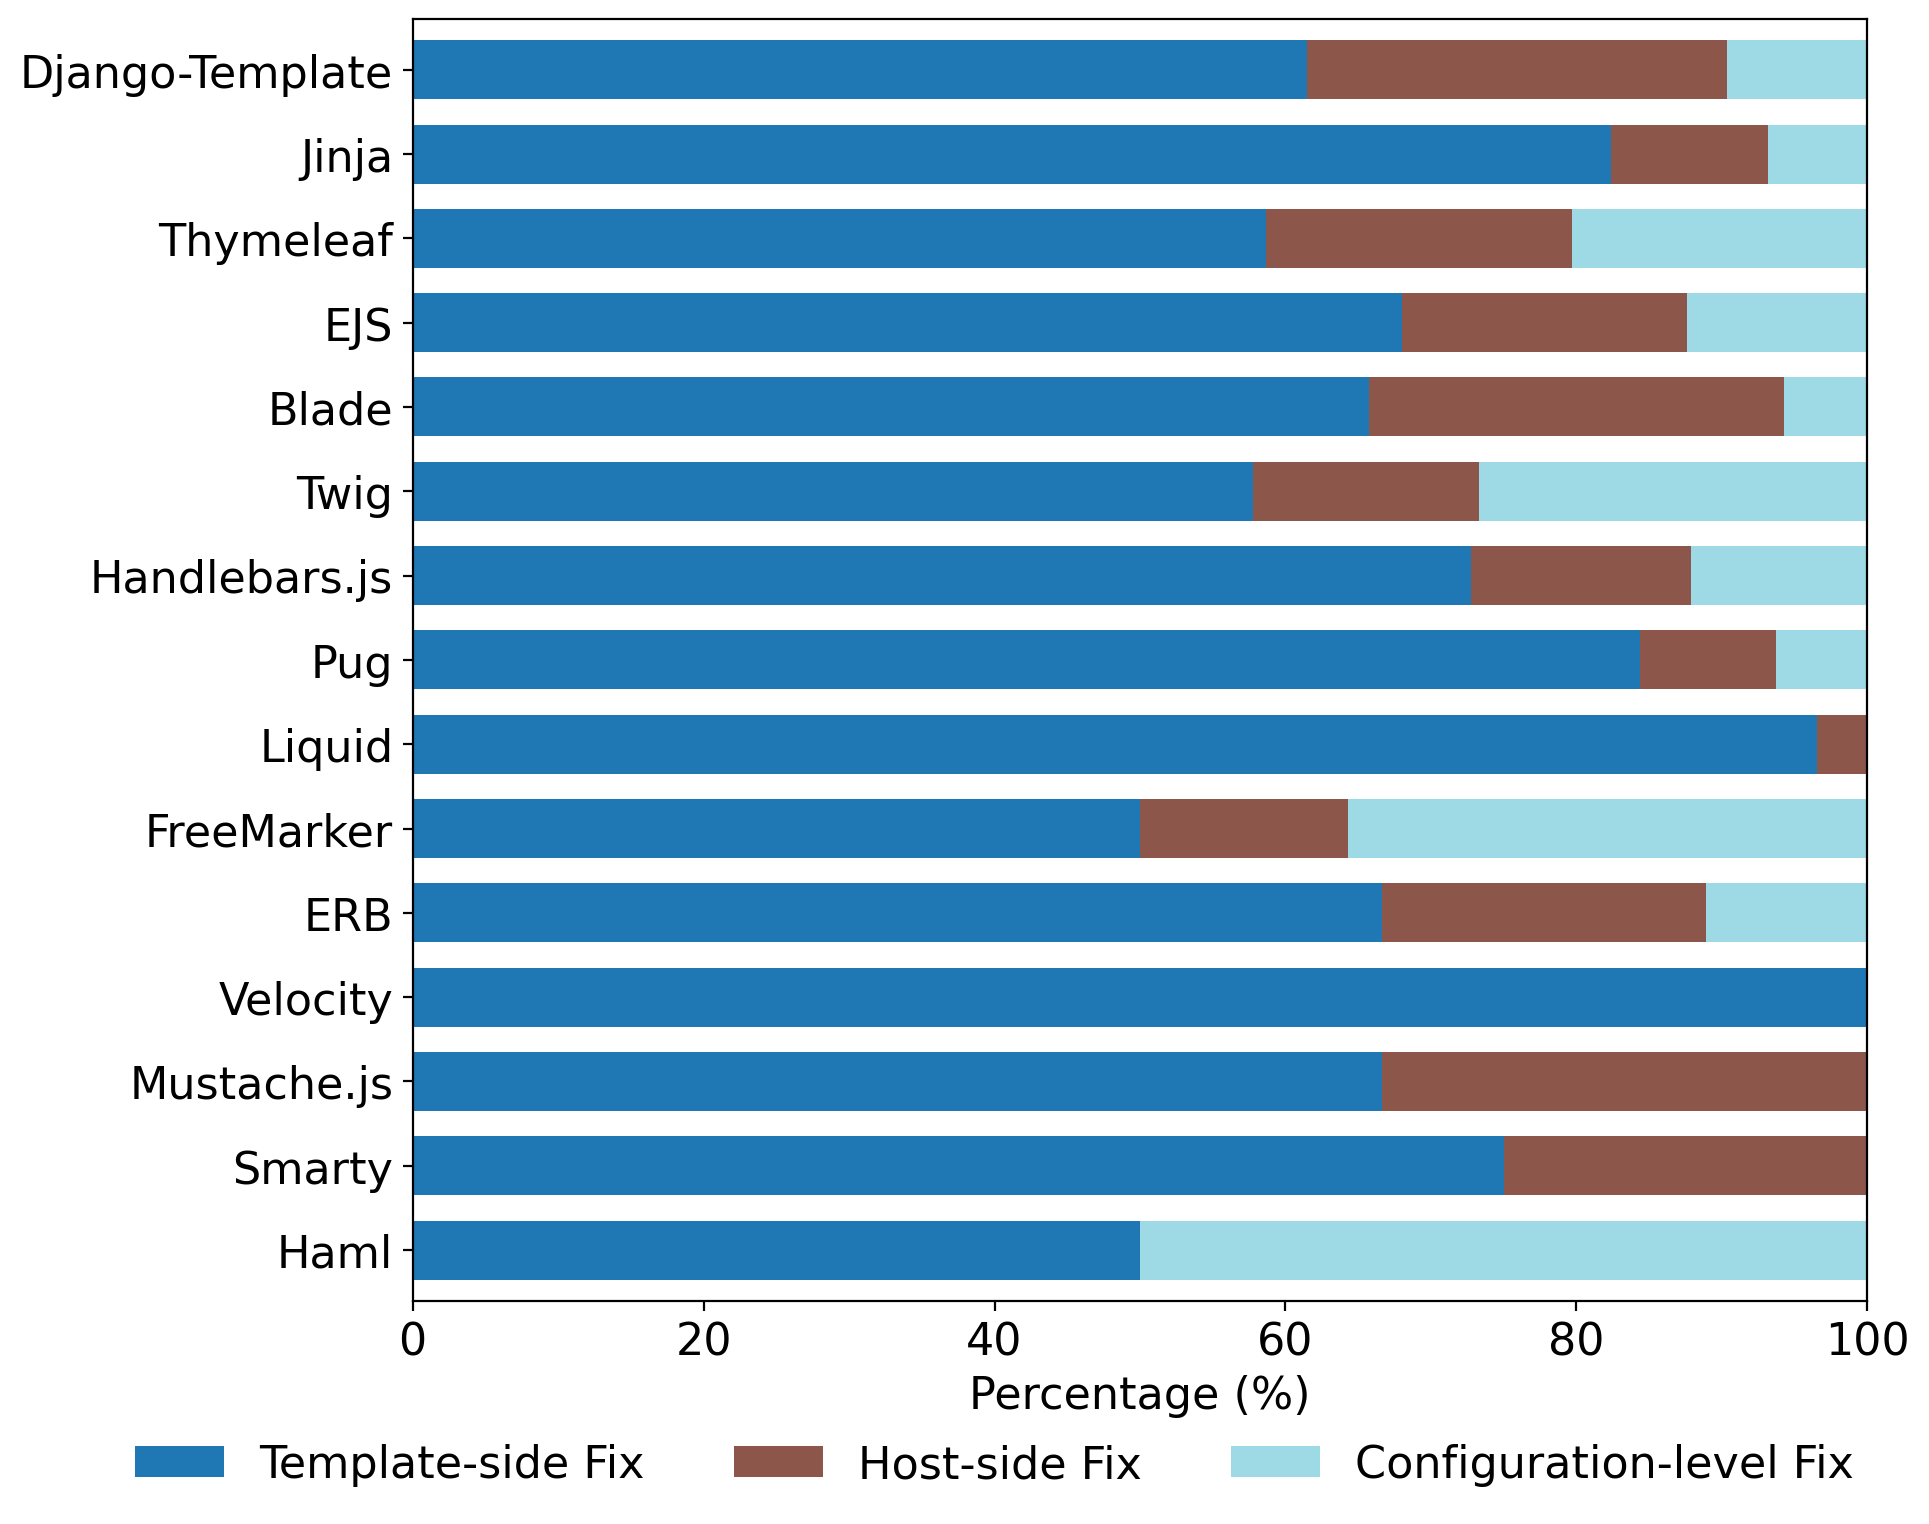

In [64]:
plot(df, "Fix Pattern", figsize=(8, 7), ticklabelsize=16, legendsize=16)

In [67]:
def print_statistics(dimension):
    data = pd.crosstab(df["Template Engine"], df[f"{dimension} Category"], normalize="index") * 100
    category_order = df[f"{dimension} Category"].value_counts().index.tolist()
    engine_order = df["Template Engine"].value_counts().index.tolist()
    return data.reindex(engine_order)[category_order].reset_index().rename_axis(None, axis=1)

In [68]:
print_statistics("Symptom")

,Template Engine,Abnormal Rendering Result,Compilation Error,Placeholder Error,Initialization Error,Others
0,Django-Template,60.550459,19.877676,9.785933,7.339450,2.446483
1,Jinja,30.337079,26.966292,36.516854,5.056180,1.123596
2,Thymeleaf,45.454545,24.475524,13.286713,13.986014,2.797203
3,EJS,46.391753,22.680412,20.618557,8.247423,2.061856
4,Blade,33.333333,33.333333,29.166667,2.777778,1.388889
5,Twig,39.130435,19.565217,26.086957,13.043478,2.173913
6,Handlebars.js,69.696970,12.121212,6.060606,12.121212,0.000000
7,Pug,48.484848,36.363636,9.090909,3.030303,3.030303
8,Liquid,62.500000,28.125000,6.250000,0.000000,3.125000
9,FreeMarker,35.714286,28.571429,21.428571,14.285714,0.000000


In [69]:
print_statistics("Root Cause")

,Template Engine,Syntax Misuse,Mismatched Data Context,Incompatible Integration,Incorrect Property Resolution,Improper Configuration,Mechanism Misconception
0,Django-Template,29.051988,25.382263,23.241590,10.703364,7.645260,3.975535
1,Jinja,47.752809,14.606742,8.988764,15.168539,3.370787,10.112360
2,Thymeleaf,36.363636,9.790210,25.874126,8.391608,13.286713,6.293706
3,EJS,28.865979,24.742268,13.402062,8.247423,17.525773,7.216495
4,Blade,37.500000,27.777778,5.555556,6.944444,4.166667,18.055556
5,Twig,36.956522,17.391304,13.043478,17.391304,6.521739,8.695652
6,Handlebars.js,27.272727,6.060606,15.151515,15.151515,24.242424,12.121212
7,Pug,42.424242,6.060606,18.181818,3.030303,18.181818,12.121212
8,Liquid,56.250000,28.125000,0.000000,3.125000,3.125000,9.375000
9,FreeMarker,28.571429,7.142857,14.285714,21.428571,7.142857,21.428571


In [70]:
print_statistics("Fix Pattern")

,Template Engine,Template-side Fix,Host-side Fix,Configuration-level Fix
0,Django-Template,61.490683,28.881988,9.627329
1,Jinja,82.386364,10.795455,6.818182
2,Thymeleaf,58.695652,21.014493,20.289855
3,EJS,68.041237,19.587629,12.371134
4,Blade,65.714286,28.571429,5.714286
5,Twig,57.777778,15.555556,26.666667
6,Handlebars.js,72.727273,15.151515,12.121212
7,Pug,84.375000,9.375000,6.250000
8,Liquid,96.551724,3.448276,0.000000
9,FreeMarker,50.000000,14.285714,35.714286


In [71]:
from scipy import stats

for dimension in ["Symptom", "Root Cause", "Fix Pattern"]:
    data = pd.crosstab(
        df["Template Engine"], df[f"{dimension} Category"], normalize="index"
    )
    print(stats.kruskal(*(data.values)))

KruskalResult(statistic=np.float64(4.64392003000317), pvalue=np.float64(0.9901773389289412))
KruskalResult(statistic=np.float64(2.5291672512496444), pvalue=np.float64(0.9996571124996513))
KruskalResult(statistic=np.float64(1.6739762219286562), pvalue=np.float64(0.9999724278078699))
